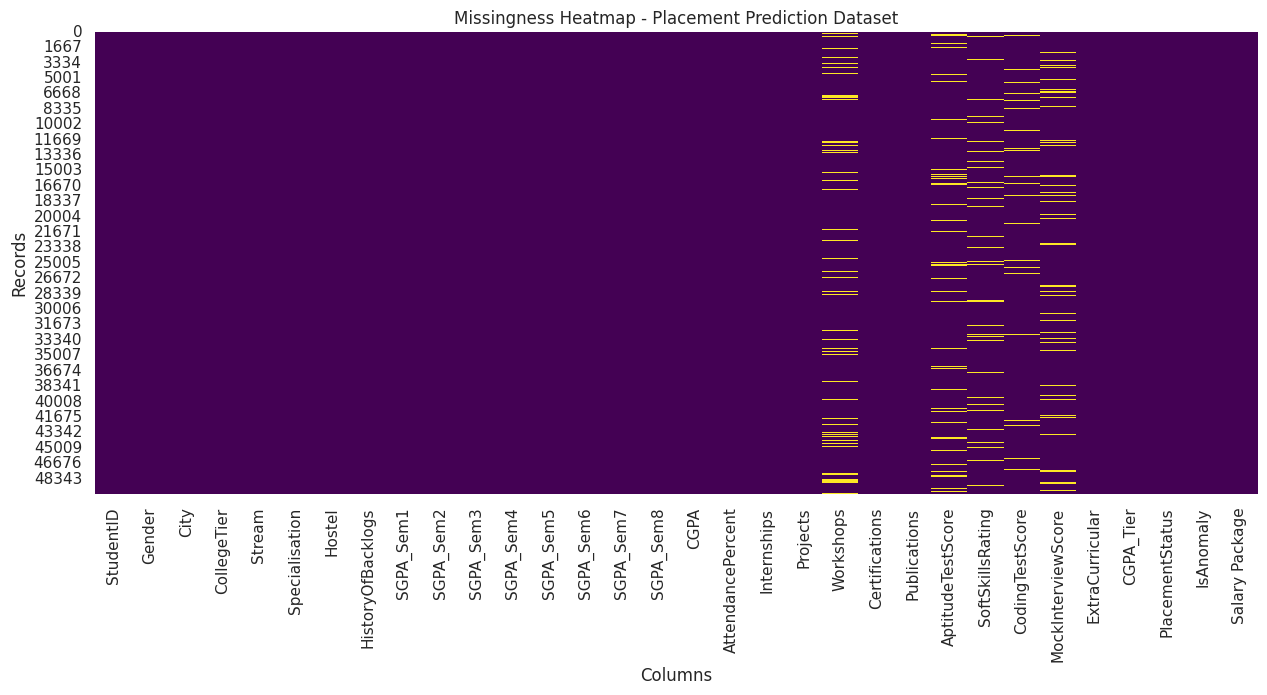

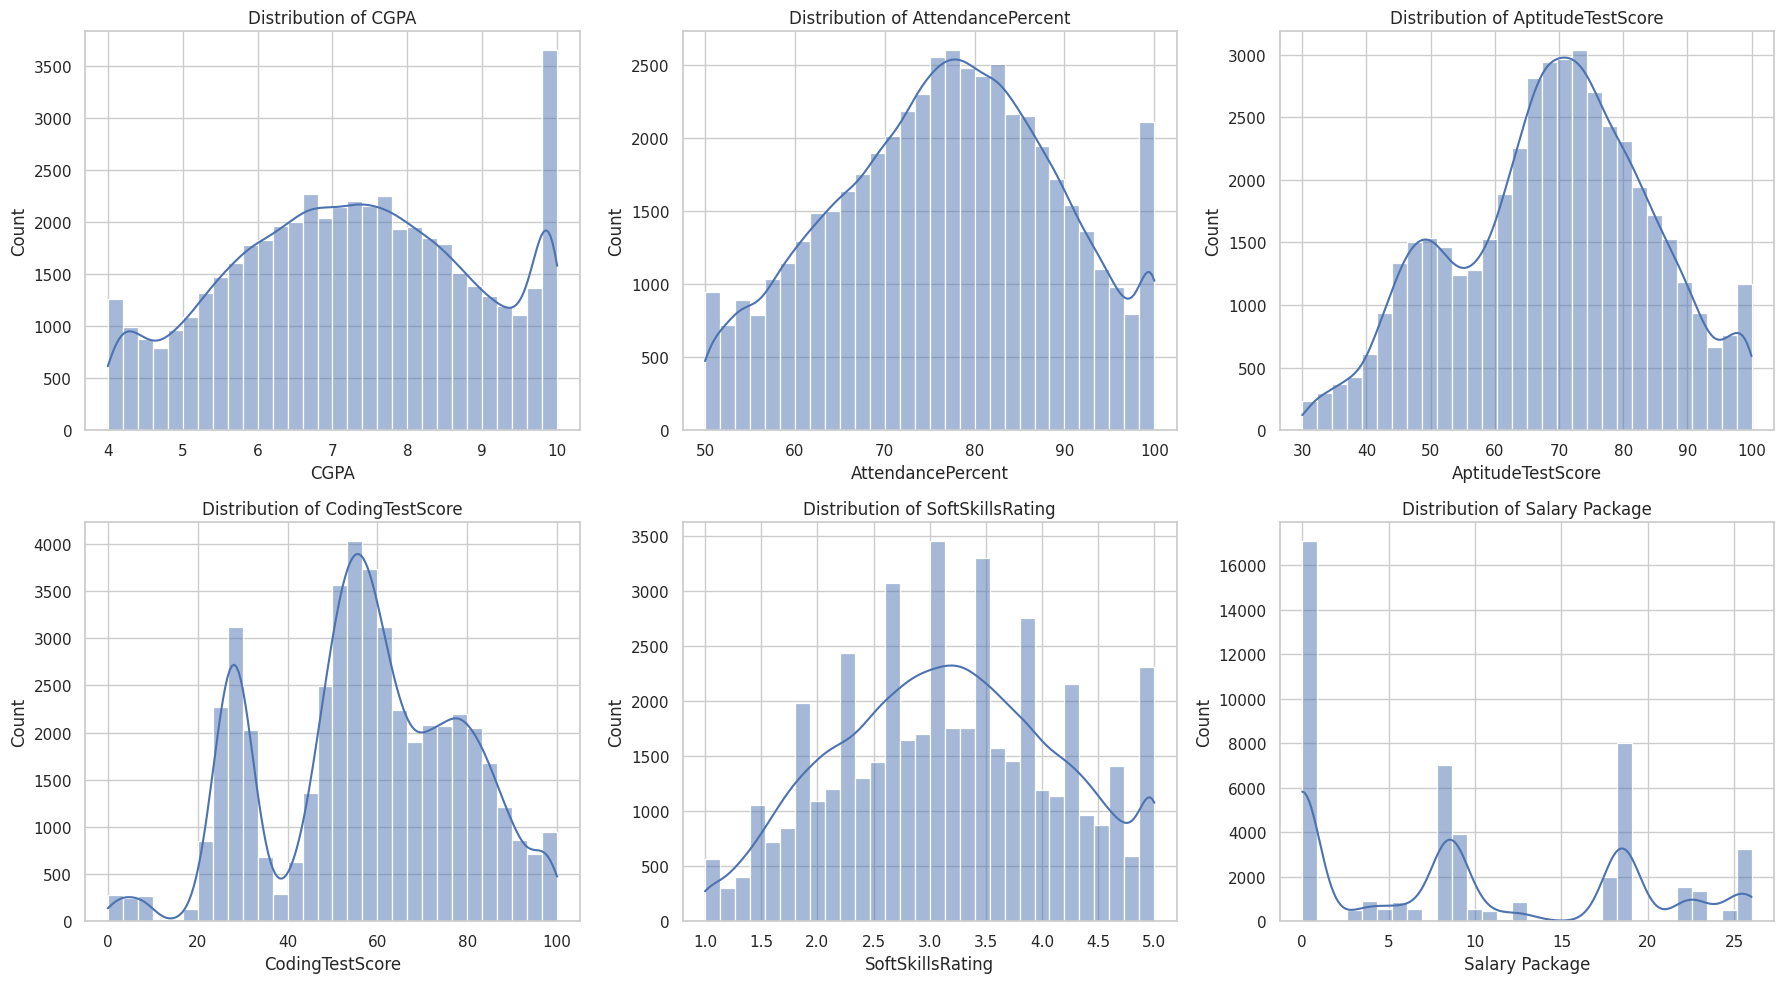

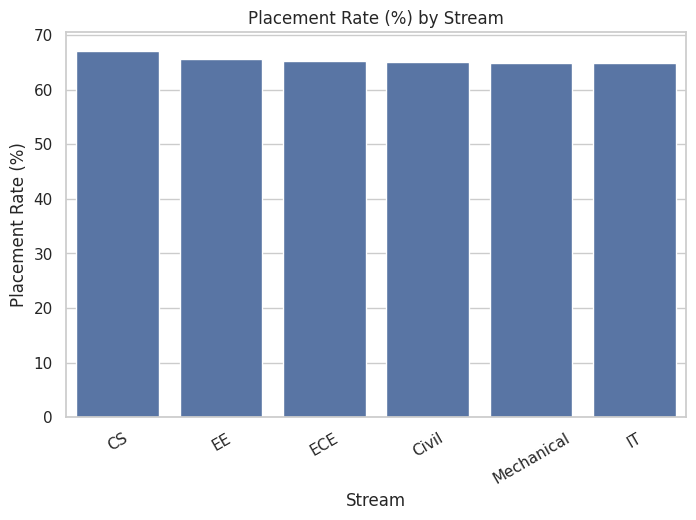

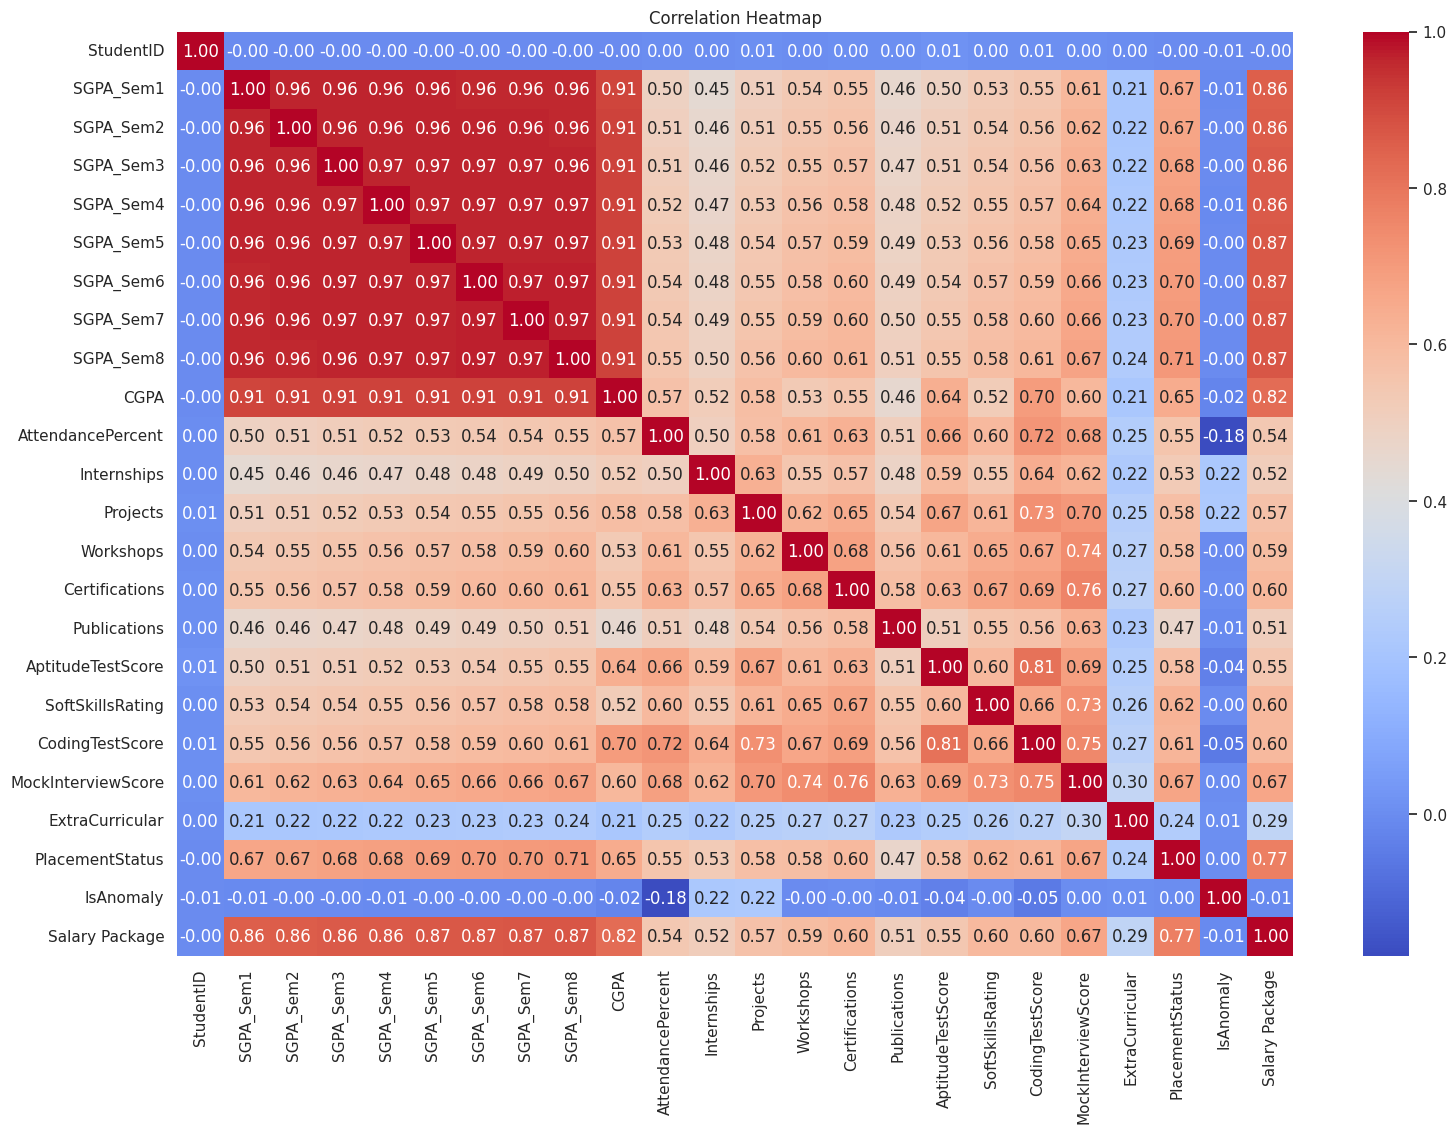

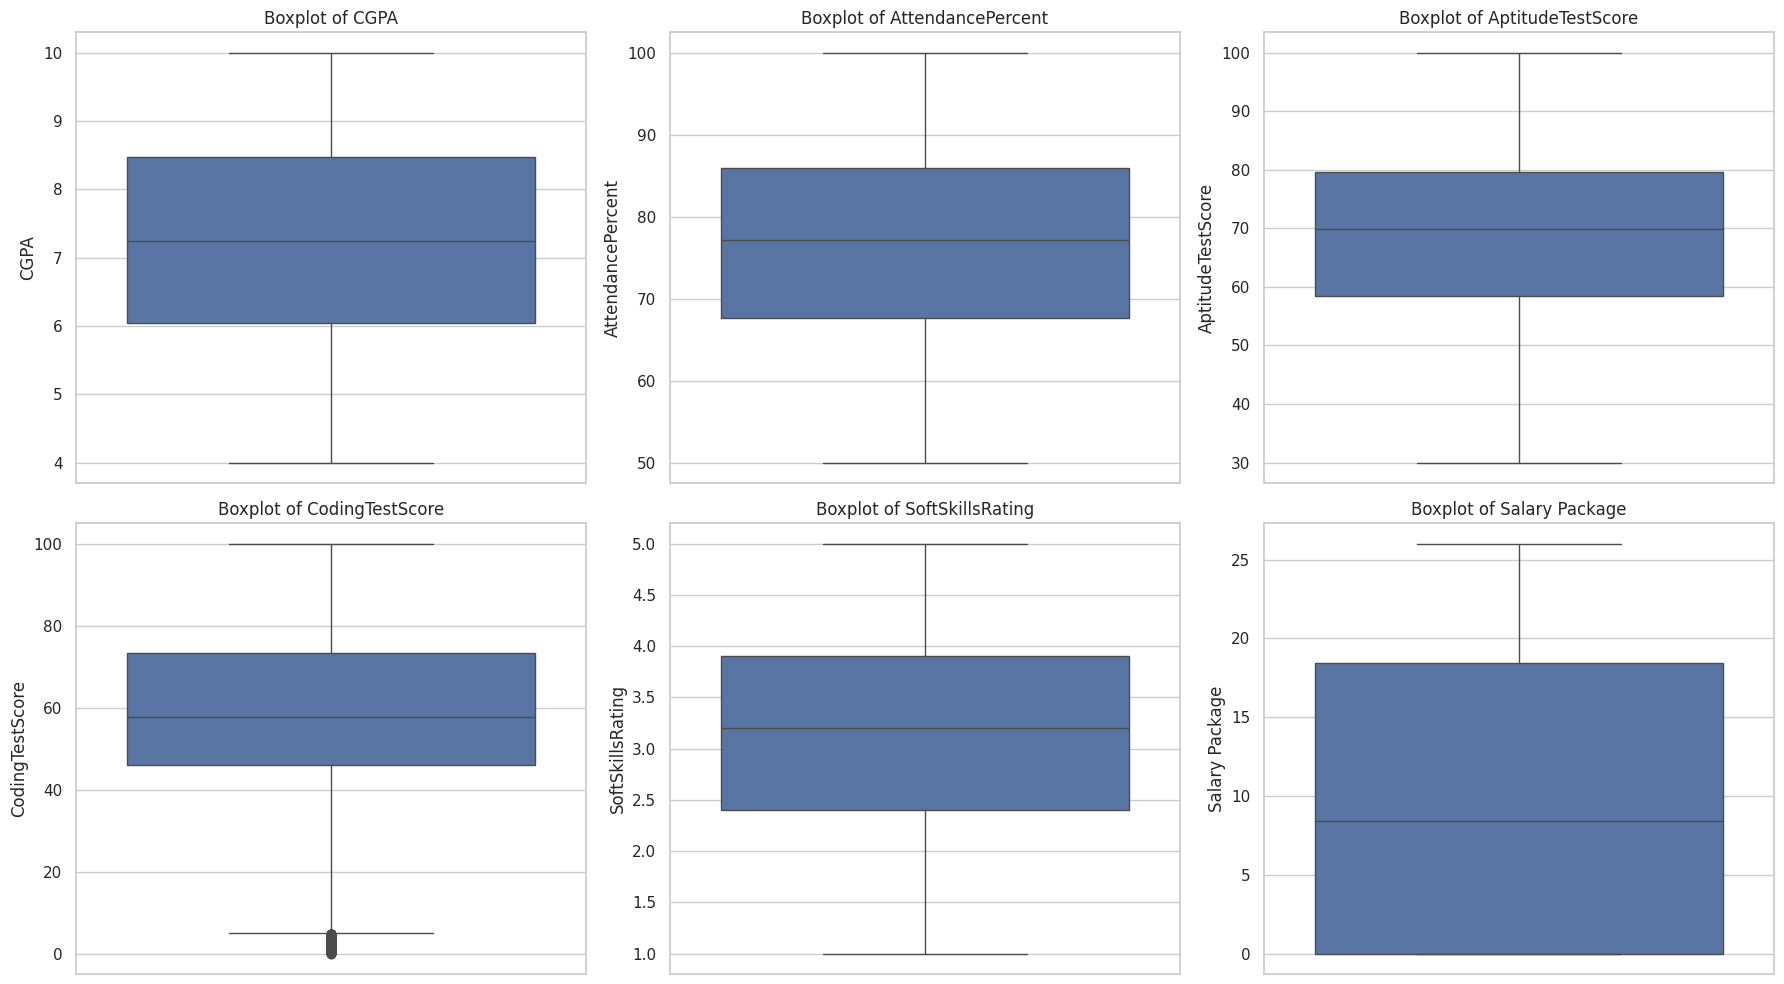

EDA Visualization Completed Successfully


In [1]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("/content/placement_predict_50k Dataset (1).csv")

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)


plt.figure(figsize=(15,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missingness Heatmap - Placement Prediction Dataset")
plt.xlabel("Columns")
plt.ylabel("Records")
plt.show()

columns = [
    "CGPA",
    "AttendancePercent",
    "AptitudeTestScore",
    "CodingTestScore",
    "SoftSkillsRating",
    "Salary Package"
]

fig, axes = plt.subplots(2,3,figsize=(18,10))

for ax,col in zip(axes.flatten(),columns):
    sns.histplot(df[col],bins=30,kde=True,ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


placement_rate = (
    df.groupby("Stream")["PlacementStatus"]
      .mean()
      .sort_values(ascending=False)*100
)

plt.figure(figsize=(8,5))
sns.barplot(x=placement_rate.index,
            y=placement_rate.values)

plt.title("Placement Rate (%) by Stream")
plt.xlabel("Stream")
plt.ylabel("Placement Rate (%)")
plt.xticks(rotation=30)
plt.show()


numeric = df.select_dtypes(include=["number"])

plt.figure(figsize=(18,12))
sns.heatmap(
    numeric.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()



box_cols = [
    "CGPA",
    "AttendancePercent",
    "AptitudeTestScore",
    "CodingTestScore",
    "SoftSkillsRating",
    "Salary Package"
]

fig,axes=plt.subplots(2,3,figsize=(18,10))

for ax,col in zip(axes.flatten(),box_cols):
    sns.boxplot(y=df[col],ax=ax)
    ax.set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

print("EDA Visualization Completed Successfully")